In [27]:
import numpy as np
from astropy.table import Table, join
from gaiaxpy import calibrate
import scipy.stats

import matplotlib.pyplot as plt

# Load in tables

In [2]:
# Load catalogs
tab_quaia = Table.read('../data/quaia_G20.5.fits')
print(len(tab_quaia))

1295502


In [22]:
# Load DR16Q property catalog and crossmatch to tab_quaia (sky position)
tab_dr16q = Table.read('../data/dr16q_prop_May01_2024.fits.gz')
print('dr16q_prop:', len(tab_dr16q))
print(tab_dr16q.columns)

dr16q_prop: 750414
<TableColumns names=('SDSS_NAME','PLATE','MJD','FIBERID','RA','DEC','OBJID','IF_BOSS_SDSS','Z_DR16Q','SOURCE_Z_DR16Q','Z_FIT','Z_SYS','Z_SYS_ERR','EBV','SN_MEDIAN_ALL','CONTI_FIT','CONTI_FIT_ERR','CONTI_STAT','FEII_UV','FEII_UV_ERR','FEII_UV_EW','FEII_UV_EW_ERR','FEII_OPT','FEII_OPT_ERR','FEII_OPT_EW','FEII_OPT_EW_ERR','LOGL1350','LOGL1350_ERR','LOGL1700','LOGL1700_ERR','LOGL2500','LOGL2500_ERR','LOGL3000','LOGL3000_ERR','LOGL5100','LOGL5100_ERR','HALPHA','HALPHA_BR','NII6585','SII6718','HBETA','HBETA_BR','HEII4687','HEII4687_BR','OIII5007','OIII5007C','CAII3934','OII3728','NEV3426','MGII','MGII_BR','CIII_ALL','CIII_BR','SIIII1892','ALIII1857','NIII1750','CIV','HEII1640','HEII1640_BR','SIIV_OIV','OI1304','LYA','NV1240','HALPHA_ERR','HALPHA_BR_ERR','NII6585_ERR','SII6718_ERR','HBETA_ERR','HBETA_BR_ERR','HEII4687_ERR','HEII4687_BR_ERR','OIII5007_ERR','OIII5007C_ERR','CAII3934_ERR','OII3728_ERR','NEV3426_ERR','MGII_ERR','MGII_BR_ERR','CIII_ALL_ERR','CIII_BR_ERR','SIIII1

In [ ]:
#print(len(tab_dr16q[tab_dr16q['Z_WARN']==0]))

In [4]:
fn_match = '../data/match_quaia_G20.5_sdss_dr16q_prop.fits'
tab_match = Table.read(fn_match)
print('match:', len(tab_match))
print(tab_match.columns)


match: 294591
<TableColumns names=('source_id','sdss_objid')>


In [ ]:
fn_hasxp = '../data/has_xp_match_quaia_G20.5_sdss_dr16q_prop.fits'
tab_hasxp = Table.read(fn_hasxp)
print('has_xp:', len(tab_hasxp))
print(tab_hasxp.columns)
print(np.sum(tab_hasxp['has_xp_continuous']))

has_xp: 294591
<TableColumns names=('source_id','has_xp_continuous','has_xp_sampled')>
35945
1


In [23]:
fn_hasxp_quaia = '../data/has_xp_quaia_G20.5.fits'
tab_hasxp_quaia = Table.read(fn_hasxp_quaia)
print('has_xp all quaia:', len(tab_hasxp_quaia))
print(np.sum(tab_hasxp_quaia['has_xp_continuous']))

has_xp all quaia: 1295502
115104


In [26]:
# DR16Q with SNR >= thresh; subset in Quaia; subset with Gaia XP spectra
thresh_snr = 10
col_snr = 'SN_MEDIAN_ALL'
tab_dr16q_inquaia = join(tab_dr16q, tab_match, keys_left='OBJID', keys_right='sdss_objid')
mask_has_xp = np.asarray(tab_hasxp['has_xp_continuous']).astype(bool)
print(np.sum(mask_has_xp))
ids_xp = tab_hasxp['source_id'][mask_has_xp]
tab_dr16q_inquaia_hasxp = tab_dr16q_inquaia[np.isin(tab_dr16q_inquaia['source_id'], ids_xp)]

print(f'DR16Q: {len(tab_dr16q)}')
print(f'  also in Quaia: {len(tab_dr16q_inquaia)}')
print(f'  also has Gaia XP: {len(tab_dr16q_inquaia_hasxp)}')

35945
DR16Q: 750414
  also in Quaia: 294591
  also has Gaia XP: 35945


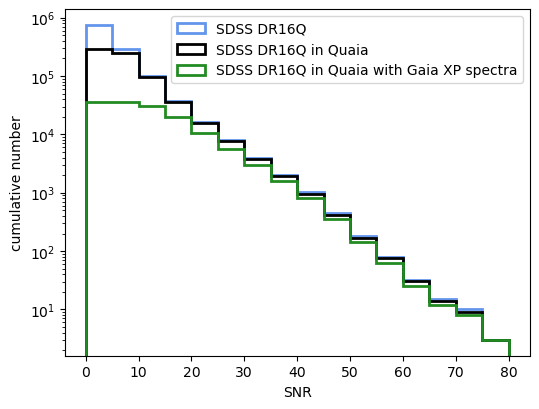

In [39]:
density = False
cumulative = -1
lw = 2
plt.figure(figsize=(6, 4.5))
bins = np.linspace(0, 80, 17)
_ = plt.hist(tab_dr16q['SN_MEDIAN_ALL'], bins=bins, density=density, cumulative=cumulative, histtype='step', lw=lw,
            label='SDSS DR16Q', color='cornflowerblue')
_ = plt.hist(tab_dr16q_inquaia['SN_MEDIAN_ALL'], bins=bins, density=density, cumulative=cumulative, histtype='step', lw=lw,
            label='SDSS DR16Q in Quaia', color='k')
_ = plt.hist(tab_dr16q_inquaia_hasxp['SN_MEDIAN_ALL'], bins=bins, density=density, cumulative=cumulative, histtype='step', lw=lw,
            label='SDSS DR16Q in Quaia with Gaia XP spectra', color='forestgreen')
plt.yscale('log')
plt.xlabel('SNR')
plt.ylabel('cumulative number')
plt.legend()
plt.show()


In [44]:
print(len(tab_dr16q_inquaia_hasxp[tab_dr16q_inquaia_hasxp[col_snr] >= 50]))
print(len(tab_dr16q_inquaia_hasxp[(tab_dr16q_inquaia_hasxp[col_snr] >= 50) & (tab_dr16q_inquaia_hasxp['Z_DR16Q'] < 0.4)]))

144
44


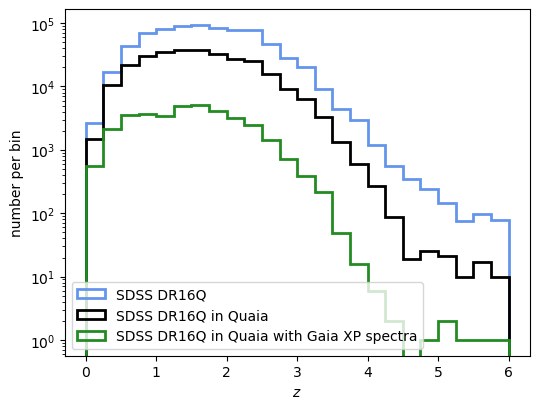

In [43]:
density = False
cumulative = False
lw = 2
plt.figure(figsize=(6, 4.5))
bins = np.linspace(0, 6, 25)
_ = plt.hist(tab_dr16q['Z_DR16Q'], bins=bins, density=density, cumulative=cumulative, histtype='step', lw=lw,
            label='SDSS DR16Q', color='cornflowerblue')
_ = plt.hist(tab_dr16q_inquaia['Z_DR16Q'], bins=bins, density=density, cumulative=cumulative, histtype='step', lw=lw,
            label='SDSS DR16Q in Quaia', color='k')
_ = plt.hist(tab_dr16q_inquaia_hasxp['Z_DR16Q'], bins=bins, density=density, cumulative=cumulative, histtype='step', lw=lw,
            label='SDSS DR16Q in Quaia with Gaia XP spectra', color='forestgreen')
plt.yscale('log')
plt.xlabel(r'$z$')
plt.ylabel('number per bin')
plt.legend()
plt.show()
